In [1]:
import pandas as pd
import numpy as np
import commodity_common_functions as CCF
import seaborn as sns
import dataframe_image as dfi
from pathlib import Path
import json
import seaborn as sns
import datetime as dt
import logging
from datetime import datetime
import os
import OptionRiskMetrixETF as ORME
import OptionRiskMetrix as ORM
import RiskManagementSystem as RMS
import matplotlib.pyplot as plt

In [2]:
SQL_cmd = f"""
SELECT *
FROM daily_data_option
WHERE trading_date >= '20220101' AND (high = limit_up)
"""
odf = pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)
odf = odf.dropna(subset=['close'])


In [3]:
und_lst = odf['underlying_instr_id'].unique().tolist()
SQL_cmd = f"""
SELECT *
FROM daily_data
WHERE instrument_id IN {tuple(und_lst)} AND trading_date >= '2022-01-01' 
"""
udf = pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)
udf['trading_date'] =  udf['trading_date'].apply(lambda x: x[:4] + x[5:7] + x[8:])

In [4]:
opt_lst = odf['instrument_id'].unique().tolist()
SQL_cmd = f"""
SELECT instrument_id, expiredate, price_tick, strike_price, options_type
FROM instrument
WHERE instrument_id IN {tuple(opt_lst)}
"""
infodf = pd.read_sql(sql=SQL_cmd, con=CCF.market_base)
infodf['options_type'] = infodf['options_type'].apply(lambda x: 'c' if x == '1' else 'p')

In [5]:
udf['amp'] = udf['high']/udf['low']-1
udf['undret'] = udf['settlement']/udf['prev_settlement']-1


In [6]:
merged_df = pd.merge(
    odf,
    udf,
    left_on=['underlying_instr_id', 'trading_date'],
    right_on=['instrument_id', 'trading_date'],
    suffixes=('_option', '_underlying')
)
merged_df

,instrument_id_option,trading_date,open_option,high_option,low_option,close_option,settlement_option,prev_settlement_option,limit_up_option,limit_down_option,...,prev_settlement_underlying,limit_up_underlying,limit_down_underlying,volume_underlying,total_turnover_underlying,open_interest_underlying,create_time_underlying,update_time_underlying,amp,undret
0,a2309-P-4850,20230619,58.5,404.5,51.5,52.5,90.5,110.5,404.5,0.5,...,4912.0,5206.0,4618.0,220947,1.103617e+10,141756.0,2023-06-19 16:05:16,2023-06-19 16:05:16,0.017168,0.016694
1,a2501-C-4200,20241008,90.0,385.5,42.0,60.5,77.5,133.5,385.5,0.5,...,4200.0,4452.0,3948.0,149136,6.041529e+09,165325.0,2024-10-08 16:06:33,2024-10-08 16:06:33,0.038501,-0.035476
2,ag2311P5800,20230921,92.0,520.5,78.0,94.0,133.5,109.5,520.5,0.5,...,5877.0,6288.0,5465.0,7985,7.057012e+08,14859.0,2023-09-21 16:06:01,2023-09-21 16:06:01,0.019007,0.002382
3,ag2402C6300,20231127,54.0,463.0,54.0,154.0,119.0,52.0,463.0,0.5,...,5873.0,6284.0,5461.0,1659755,1.504657e+11,557758.0,2023-11-27 16:06:14,2023-11-27 16:06:14,0.070223,0.028946
4,ag2402C6500,20231127,33.5,435.5,31.5,104.5,69.0,24.5,435.5,0.5,...,5873.0,6284.0,5461.0,1659755,1.504657e+11,557758.0,2023-11-27 16:06:14,2023-11-27 16:06:14,0.070223,0.028946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,ZC205C800,20220307,90.2,162.3,90.0,162.2,114.2,78.3,162.3,0.1,...,838.2,922.2,754.2,6536,5.832726e+06,10501.0,2022-11-15 17:32:13,2022-11-15 17:32:13,0.101533,0.064662
646,zn2204C25500,20220308,1695.0,3360.0,1072.0,2700.0,1840.0,1254.0,3360.0,1.0,...,26335.0,28440.0,24225.0,367007,4.959273e+10,115826.0,2022-11-15 17:32:13,2022-11-15 17:32:13,0.081986,0.026201
647,zn2204C26500,20220308,1012.0,2808.0,530.0,1962.0,1180.0,702.0,2808.0,1.0,...,26335.0,28440.0,24225.0,367007,4.959273e+10,115826.0,2022-11-15 17:32:13,2022-11-15 17:32:13,0.081986,0.026201
648,zn2309C21600,20230524,141.0,1598.0,113.0,123.0,141.0,215.0,1598.0,1.0,...,19770.0,21150.0,18385.0,13063,1.256032e+09,12211.0,2023-05-24 16:05:42,2023-05-24 16:05:42,0.027924,-0.027314


In [7]:
merged_df = pd.merge(
    merged_df,
    infodf,
    left_on=['instrument_id_option'],
    right_on=['instrument_id']
)
merged_df

,instrument_id_option,trading_date,open_option,high_option,low_option,close_option,settlement_option,prev_settlement_option,limit_up_option,limit_down_option,...,open_interest_underlying,create_time_underlying,update_time_underlying,amp,undret,instrument_id,expiredate,price_tick,strike_price,options_type
0,a2309-P-4850,20230619,58.5,404.5,51.5,52.5,90.5,110.5,404.5,0.5,...,141756.0,2023-06-19 16:05:16,2023-06-19 16:05:16,0.017168,0.016694,a2309-P-4850,20230807,0.5,4850.0,p
1,a2501-C-4200,20241008,90.0,385.5,42.0,60.5,77.5,133.5,385.5,0.5,...,165325.0,2024-10-08 16:06:33,2024-10-08 16:06:33,0.038501,-0.035476,a2501-C-4200,20241217,0.5,4200.0,c
2,ag2311P5800,20230921,92.0,520.5,78.0,94.0,133.5,109.5,520.5,0.5,...,14859.0,2023-09-21 16:06:01,2023-09-21 16:06:01,0.019007,0.002382,ag2311P5800,20231025,0.5,5800.0,p
3,ag2402C6300,20231127,54.0,463.0,54.0,154.0,119.0,52.0,463.0,0.5,...,557758.0,2023-11-27 16:06:14,2023-11-27 16:06:14,0.070223,0.028946,ag2402C6300,20240125,0.5,6300.0,c
4,ag2402C6500,20231127,33.5,435.5,31.5,104.5,69.0,24.5,435.5,0.5,...,557758.0,2023-11-27 16:06:14,2023-11-27 16:06:14,0.070223,0.028946,ag2402C6500,20240125,0.5,6500.0,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,ZC205C800,20220307,90.2,162.3,90.0,162.2,114.2,78.3,162.3,0.1,...,10501.0,2022-11-15 17:32:13,2022-11-15 17:32:13,0.101533,0.064662,ZC205C800,20220407,0.1,800.0,c
646,zn2204C25500,20220308,1695.0,3360.0,1072.0,2700.0,1840.0,1254.0,3360.0,1.0,...,115826.0,2022-11-15 17:32:13,2022-11-15 17:32:13,0.081986,0.026201,zn2204C25500,20220325,1.0,25500.0,c
647,zn2204C26500,20220308,1012.0,2808.0,530.0,1962.0,1180.0,702.0,2808.0,1.0,...,115826.0,2022-11-15 17:32:13,2022-11-15 17:32:13,0.081986,0.026201,zn2204C26500,20220325,1.0,26500.0,c
648,zn2309C21600,20230524,141.0,1598.0,113.0,123.0,141.0,215.0,1598.0,1.0,...,12211.0,2023-05-24 16:05:42,2023-05-24 16:05:42,0.027924,-0.027314,zn2309C21600,20230825,1.0,21600.0,c


In [8]:
merged_df['ttm'] = (pd.to_datetime(merged_df['expiredate'], format='%Y%m%d') - pd.to_datetime(merged_df['trading_date'], format='%Y%m%d')).dt.days/365

In [9]:
merged_df['optionlimitds'] =(merged_df['limit_up_underlying']/merged_df['prev_settlement_underlying']-1) * merged_df['prev_settlement_underlying']
# merged_df['iv'] = merged_df.apply(lambda x: CCF.IV(x['close_option'], x['close_underlying'], x['strike_price'], x['ttm'], 0, x['options_type']), axis=1)
# merged_df['delta'] = merged_df.apply(lambda x: CCF.BSMgreeks.delta(x['options_type'], x['close_underlying'], x['strike_price'], x['ttm'], 0, x['iv'], 0), axis=1)

In [10]:
merged_df['isOTM'] = (merged_df['prev_settlement_underlying'] > merged_df['strike_price']) & (merged_df['options_type'] == 'p') | (merged_df['prev_settlement_underlying'] < merged_df['strike_price']) & (merged_df['options_type'] == 'c')

In [11]:
merged_df['isseal'] = merged_df['close_option'] == merged_df['high_option']

In [12]:
# merged_df.to_excel('./merged_df.xlsx', index=False)

In [12]:
# testday = '20250407'
# optside = 'p'
# und_id = 'sc2505'

In [114]:
testday = '20240529'
optside = 'c'
und_id = 'sn2507'

In [115]:
und_prevclose = udf[(udf['trading_date'] == testday) & (udf['instrument_id'] == und_id)].iloc[0]['prev_settlement']
info = RMS.findAllInfo(testday)
for key in info:
    if key[0] == und_id:
        thisinfo = info[key]
        break

IndexError: single positional indexer is out-of-bounds

In [104]:
und_close = udf[(udf['trading_date'] == testday) & (udf['instrument_id'] == und_id)].iloc[0]['close']
SQL_cmd = f"""
SELECT *
FROM daily_data_option
WHERE trading_date = '{testday}' AND underlying_instr_id = '{und_id}'
"""
dayoptionprice = pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)

In [105]:
def extract_option_info(instrument_id):
    # Split by '-' for format like sc2505-p-550
    if '-' in instrument_id:
        parts = instrument_id.split('-')
        opt_type = parts[1].lower()
        strike = float(parts[2])
    # For format like sc2505C550, find the letter after the number part
    else:
        # Find the position after the number part
        flag = False
        for i in range(len(instrument_id)):
            if(instrument_id[i].isdigit()):
                flag =  True
            if(flag):
                if(instrument_id[i].isalpha()):
                    ind = i
                    break
        opt_type = instrument_id[ind].lower()
        strike = float(instrument_id[ind+1:])
    return pd.Series([opt_type, strike])

dayoptionprice[['opt_type', 'strike']] = dayoptionprice['instrument_id'].apply(extract_option_info)
optselect = dayoptionprice[(dayoptionprice['opt_type'] == optside)]
optselect = optselect[optselect['strike'] < und_prevclose if optside == 'p' else optselect['strike'] > und_prevclose].sort_values('strike')


In [106]:
spreaddf = pd.DataFrame()
for i in optselect['instrument_id']:
    thisdf = CCF.Option_Raw_Data(i, testday)
    thisdf['updatetime'] = thisdf['id'].apply(lambda x: f'{x[8:10]}:{x[10:12]}')
    thisdf = thisdf.groupby('updatetime').first().sort_values('id')
    thisdf['spread'] = thisdf['Ask1'] - thisdf['Bid1']
    thisdf['spreadTick'] = thisdf['spread']/thisinfo['price_tick']
    spreaddf[i] = thisdf['spreadTick']


In [107]:
spreaddf = spreaddf.clip(lower=0)

In [108]:
desdf = spreaddf.loc[spreaddf.index[spreaddf.index.get_loc('09:00'):]].describe()
for ins in desdf.columns:
    row = optselect[optselect['instrument_id'] == ins]
    vol = row['volume'].values[0]
    oi = row['open_interest'].values[0]
    desdf.loc['vol', ins] = vol
    desdf.loc['oi', ins] = oi
    desdf.loc['vol/oi', ins] = vol/oi
    desdf.loc['strike', ins] = row['strike'].values[0]



In [109]:
desdf.round(2).to_excel(f'./temp/{testday}_{und_id}_spreaddf.xlsx')

In [110]:
desdf

,ag2406C7600,ag2406C7700,ag2406C7800,ag2406C7900,ag2406C8000,ag2406C8100,ag2406C8200,ag2406C8300,ag2406C8400,ag2406C8500
count,95.000000,121.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
mean,49.673684,44.289256,20.320175,28.741228,13.574561,20.197368,10.114035,5.017544,10.947368,3.043860
std,38.494388,30.130947,15.335259,17.865594,10.095084,16.876608,8.257698,4.683804,7.087051,2.440085
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,29.500000,33.000000,8.750000,16.000000,7.000000,12.000000,4.750000,2.000000,7.000000,1.000000
50%,44.000000,43.000000,16.500000,27.000000,11.500000,18.000000,9.000000,4.000000,10.000000,2.000000
75%,58.500000,54.000000,28.000000,37.250000,18.000000,24.000000,13.000000,6.000000,14.000000,4.000000
max,207.000000,306.000000,91.000000,109.000000,86.000000,188.000000,68.000000,46.000000,58.000000,17.000000
vol,8526.000000,13313.000000,48743.000000,35768.000000,82948.000000,27123.000000,31241.000000,93522.000000,13762.000000,82857.000000
oi,2474.000000,2581.000000,8019.000000,4408.000000,7408.000000,4292.000000,6688.000000,15814.000000,2561.000000,13674.000000


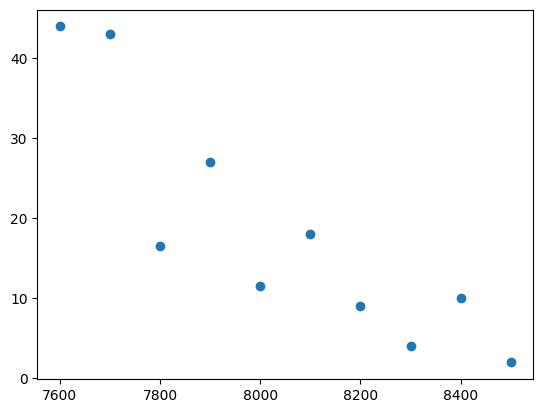

In [111]:
plt.scatter(desdf.T['strike'], desdf.T['50%'])
plt.savefig(f'./temp/{testday}_{und_id}_strkevsmidspread.png')

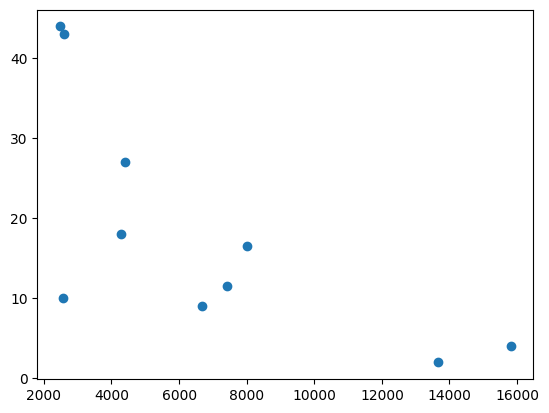

In [112]:
plt.scatter(desdf.T['oi'], desdf.T['50%'])
plt.savefig(f'./temp/{testday}_{und_id}_oi_vsmidspread.png')

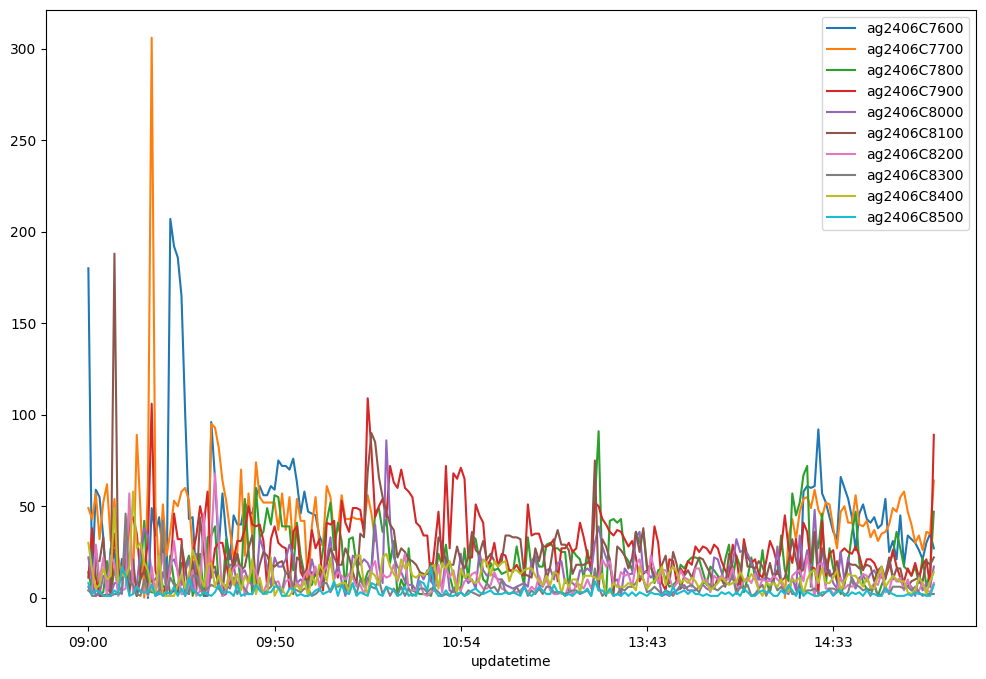

In [113]:
spreaddf.loc[spreaddf.index[spreaddf.index.get_loc('09:00'):]].plot(figsize=(12, 8), legend='best')
spreaddf
plt.savefig(f'./temp/{testday}_{und_id}_spreadday.png')
spreaddf.to_excel(f'./temp/{testday}_{und_id}_spreadday.xlsx')

In [47]:
spreaddf

,TA505P4300,TA505P4350,TA505P4400,TA505P4450,TA505P4500,TA505P4550,TA505P4600,TA505P4650,TA505P4700,TA505P4750,TA505P4800
updatetime,,,,,,,,,,,
21:00,16.0,503.0,33.0,106.0,20.0,-160.0,14.0,304.0,10.0,10.0,2.0
21:01,16.0,503.0,33.0,106.0,20.0,-160.0,14.0,304.0,10.0,10.0,2.0
21:02,16.0,503.0,33.0,106.0,20.0,-160.0,14.0,304.0,10.0,10.0,2.0
21:03,16.0,503.0,33.0,106.0,20.0,-160.0,14.0,304.0,10.0,10.0,2.0
21:04,16.0,503.0,33.0,106.0,20.0,-160.0,14.0,304.0,10.0,10.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
14:56,1.0,19.0,1.0,39.0,2.0,14.0,27.0,-592.0,-598.0,-609.0,-632.0
14:57,19.0,82.0,39.0,21.0,1.0,10.0,4.0,-592.0,-598.0,-609.0,-632.0
14:58,1.0,13.0,10.0,30.0,11.0,83.0,2.0,-592.0,-598.0,-609.0,-632.0


In [32]:
thisdf

,id,seq_no,Bid1,Ask1,MidPrice,spread,spreadTick
updatetime,,,,,,,
21:00,20250404210000000,0,9.95,15.00,12.475,5.05,101.0
21:01,20250404210100000,120,9.95,15.00,12.475,5.05,101.0
21:02,20250404210200000,240,9.95,15.00,12.475,5.05,101.0
21:03,20250404210300000,360,9.95,15.00,12.475,5.05,101.0
21:04,20250404210400000,480,9.95,15.00,12.475,5.05,101.0
...,...,...,...,...,...,...,...
14:56,20250407145600000,66120,9.55,9.75,9.650,0.20,4.0
14:57,20250407145700000,66240,9.60,9.90,9.750,0.30,6.0
14:58,20250407145800000,66360,9.30,9.45,9.375,0.15,3.0


In [2]:
import RiskManagementSystem as RMS
nakedputprev = RMS.OptionPortfolio('sc2505', {'sc2505P450':-10}, '20250403')
nakedputtoday = RMS.OptionPortfolio('sc2505', {'sc2505P450':-10}, '20250407')

covputprev = RMS.OptionPortfolio('sc2505', {'sc2505P450':-10, 'sc2505P490':3}, '20250403')
covputtoday = RMS.OptionPortfolio('sc2505', {'sc2505P450':-10, 'sc2505P490':3}, '20250407')


In [7]:
nakedputtoday.calMTMpnl(500)

(-95000.0, -97500.0)

In [4]:
nakedputprev.calMMPortfolioPrice()

(-1000.0, -1000.0, -1500.0)

In [5]:
500/750000/11*365

0.02212121212121212

In [46]:
nakedputprev.cdtm

11

In [41]:
nakedputprev.margin

np.float64(225000.0)

In [42]:
nakedputtoday.margin

np.float64(293112.0)

In [43]:
293112/225000.0

1.30272

In [38]:
nakedputprev.und_price

np.float64(542.0)

In [40]:
nakedputtoday.und_price

np.float64(510.1)

In [32]:
print("nakedputprev", nakedputprev.calMMPortfolioPrice())
print("nakedputtoday", nakedputtoday.calMMPortfolioPrice())
print("covputprev", covputprev.calMMPortfolioPrice())
print("covputtoday", covputtoday.calMMPortfolioPrice())

nakedputprev (-300.00000000000006, -300.00000000000006, -449.99999999999994)
nakedputtoday (-28349.999999999996, -28650.000000000004, -29099.999999999996)
covputprev (199.99999999999994, 199.99999999999994, 5.684341886080802e-14)
covputtoday (-449.99999999999636, -1050.0000000000036, -2199.9999999999964)


In [33]:
nakedputprev.cdtm

11

In [34]:
nakedputprev.calMTMGreeksInfo('cdtm')

{'sc2505P450': {'underlying_instr_id': 'sc2505',
  'expiredate': '20250414',
  'options_type': 'p',
  'strike_price': 450.0,
  'position': -3,
  'ask': 0.15,
  'bid': 0.1,
  'close': np.float64(0.1),
  'iv': 0.4566945682552477,
  'delta': np.float64(-0.008518158540914506),
  'gamma': np.float64(0.0005390095054592013),
  'vega': np.float64(0.021793182922486266),
  'theta': np.float64(-0.04524012848042046),
  'method': 'cdtm'}}

In [35]:
nakedputtoday.calMTMGreeksInfo('cdtm')

{'sc2505P450': {'underlying_instr_id': 'sc2505',
  'expiredate': '20250414',
  'options_type': 'p',
  'strike_price': 450.0,
  'position': -3,
  'ask': 9.7,
  'bid': 9.55,
  'close': np.float64(9.45),
  'iv': np.float64(1.163426779843419),
  'delta': np.float64(-0.19527476488670822),
  'gamma': np.float64(0.0033575736899340495),
  'vega': np.float64(0.19493078507246367),
  'theta': np.float64(-1.6199121112086146),
  'method': 'cdtm'}}

In [36]:
covputprev.calMTMGreeksInfo('cdtm')

{'sc2505P450': {'underlying_instr_id': 'sc2505',
  'expiredate': '20250414',
  'options_type': 'p',
  'strike_price': 450.0,
  'position': -3,
  'ask': 0.15,
  'bid': 0.1,
  'close': np.float64(0.1),
  'iv': 0.4566945682552477,
  'delta': np.float64(-0.008518158540914506),
  'gamma': np.float64(0.0005390095054592013),
  'vega': np.float64(0.021793182922486266),
  'theta': np.float64(-0.04524012848042046),
  'method': 'cdtm'},
 'sc2505P490': {'underlying_instr_id': 'sc2505',
  'expiredate': '20250414',
  'options_type': 'p',
  'strike_price': 490.0,
  'position': 1,
  'ask': 0.5,
  'bid': 0.45,
  'close': np.float64(0.5),
  'iv': 0.33131555687851943,
  'delta': np.float64(-0.03734564347594254),
  'gamma': np.float64(0.0026138921051327485),
  'vega': np.float64(0.0766704265478083),
  'theta': np.float64(-0.11546411394454875),
  'method': 'cdtm'}}

In [37]:
covputtoday.calMTMGreeksInfo('cdtm')

{'sc2505P450': {'underlying_instr_id': 'sc2505',
  'expiredate': '20250414',
  'options_type': 'p',
  'strike_price': 450.0,
  'position': -3,
  'ask': 9.7,
  'bid': 9.55,
  'close': np.float64(9.45),
  'iv': np.float64(1.163426779843419),
  'delta': np.float64(-0.19527476488670822),
  'gamma': np.float64(0.0033575736899340495),
  'vega': np.float64(0.19493078507246367),
  'theta': np.float64(-1.6199121112086146),
  'method': 'cdtm'},
 'sc2505P490': {'underlying_instr_id': 'sc2505',
  'expiredate': '20250414',
  'options_type': 'p',
  'strike_price': 490.0,
  'position': 1,
  'ask': 27.6,
  'bid': 26.9,
  'close': np.float64(27.9),
  'iv': np.float64(1.3203426035488781),
  'delta': np.float64(-0.3777913544773061),
  'gamma': np.float64(0.004074966884818282),
  'vega': np.float64(0.26848902842623795),
  'theta': np.float64(-2.532125020118627),
  'method': 'cdtm'}}

In [9]:
nakedputprev.margin

np.float64(61830.0)

In [10]:
nakedputtoday.margin

np.float64(78405.0)

In [12]:
covputprev.calMMPortfolioPrice()

(-160.0, -165.0, -195.0)

In [13]:
covputtoday.calMMPortfolioPrice()

(-7045.0, -5535.0, -6300.0)